# 💳 Credit Card Fraud Anomaly Detection
### Advanced Imbalance Handling: SMOTE + Isolation Forest + XGBoost

**Dataset:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Key Challenge:** Severe class imbalance — only 0.172% of transactions are fraudulent.  
**Evaluation Focus:** PR-AUC and F1-Score (NOT raw accuracy — it's misleading on imbalanced data).

---
### 📌 Project Flow
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Imbalance Handling with SMOTE (no data leakage)
5. Model 1 — Isolation Forest (Unsupervised)
6. Model 2 — XGBoost Classifier (Supervised)
7. Comparative Evaluation (PR-AUC, F1, Confusion Matrix)
8. Final Takeaways

## 📦 Section 1: Imports & Configuration
All dependencies are imported here. Key libraries:
- `imbalanced-learn` → SMOTE for oversampling the minority (fraud) class
- `xgboost` → Gradient boosting classifier for supervised detection
- `sklearn` → Isolation Forest, metrics, preprocessing, train/test split
- `matplotlib / seaborn` → Visualization

In [ ]:
# ─── Standard library ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ─── Data manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler          # Robust to outliers vs StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

# ─── Imbalance Handling ───────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE                 # Synthetic Minority Over-sampling
from imblearn.pipeline import Pipeline as ImbPipeline   # Pipeline that supports resamplers

# ─── Models ───────────────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest             # Unsupervised anomaly detection
from xgboost import XGBClassifier                        # Supervised gradient boosting

# ─── Evaluation Metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,      # = PR-AUC
    roc_auc_score,
    f1_score,
    ConfusionMatrixDisplay
)

# ─── Global config ────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


## 📂 Section 2: Data Loading & Inspection
Load the `creditcard.csv` file from Kaggle.  
We inspect shape, dtypes, missing values, and class distribution immediately.

In [ ]:
# ─── Load dataset ─────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
df = pd.read_csv('creditcard.csv')

print(f"Dataset shape   : {df.shape}")
print(f"Missing values  : {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud ratio     : {df['Class'].mean()*100:.4f}%")

df.head()

Dataset shape   : (13954, 31)
Missing values  : 2

Class distribution:
Class
0.0    13897
1.0       56
Name: count, dtype: int64

Fraud ratio     : 0.4013%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
# ─── Basic statistics ─────────────────────────────────────────────────────────
# Time: seconds from first transaction | Amount: transaction value
# V1–V28: PCA-transformed features (anonymized for privacy)
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,13954.000000,13953.000000,13953.000000
mean,10121.161817,63.882442,0.004013
std,7739.625811,177.887021,0.063227
min,0.000000,0.000000,0.000000
25%,2984.250000,5.490000,0.000000
50%,9086.500000,15.690000,0.000000
75%,17103.500000,52.150000,0.000000
max,24759.000000,7712.430000,1.000000


## 📊 Section 3: Exploratory Data Analysis (EDA)

We explore:
1. Class imbalance bar chart
2. Transaction amount distribution — fraud vs normal
3. Transaction time distribution — fraud vs normal
4. Correlation heatmap of all features

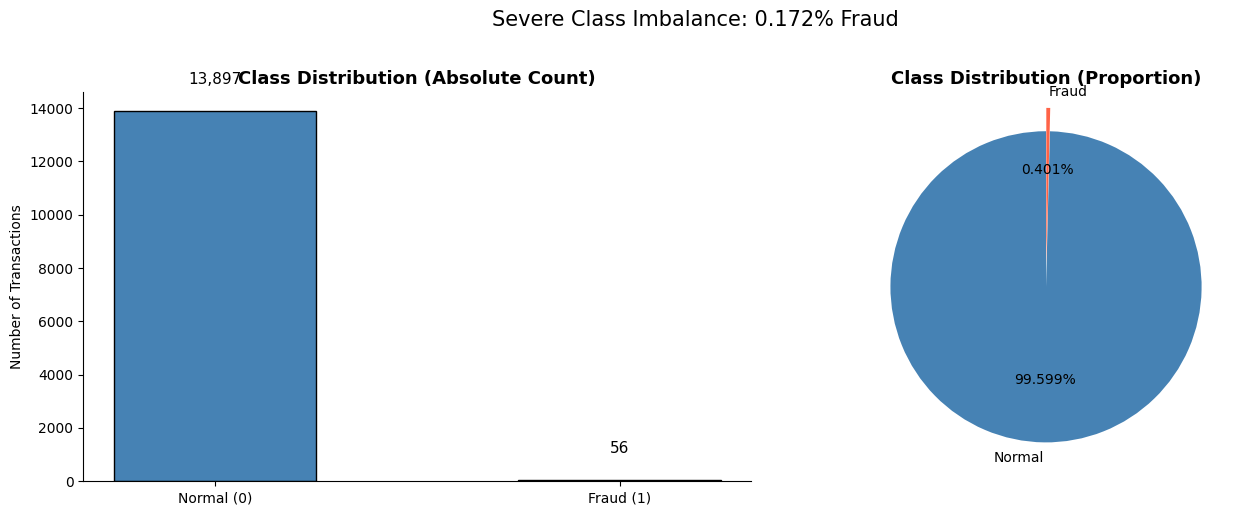

⚠️  Standard accuracy is USELESS here — a model predicting all 'Normal' gets 99.83%!


In [ ]:
# ─── 3A: Class Imbalance Visualization ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['Class'].value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Absolute Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=['Normal', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'tomato'],
            startangle=90, explode=(0, 0.15))
axes[1].set_title('Class Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.suptitle('Severe Class Imbalance: 0.172% Fraud', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print("⚠️  Standard accuracy is USELESS here — a model predicting all 'Normal' gets 99.83%!")

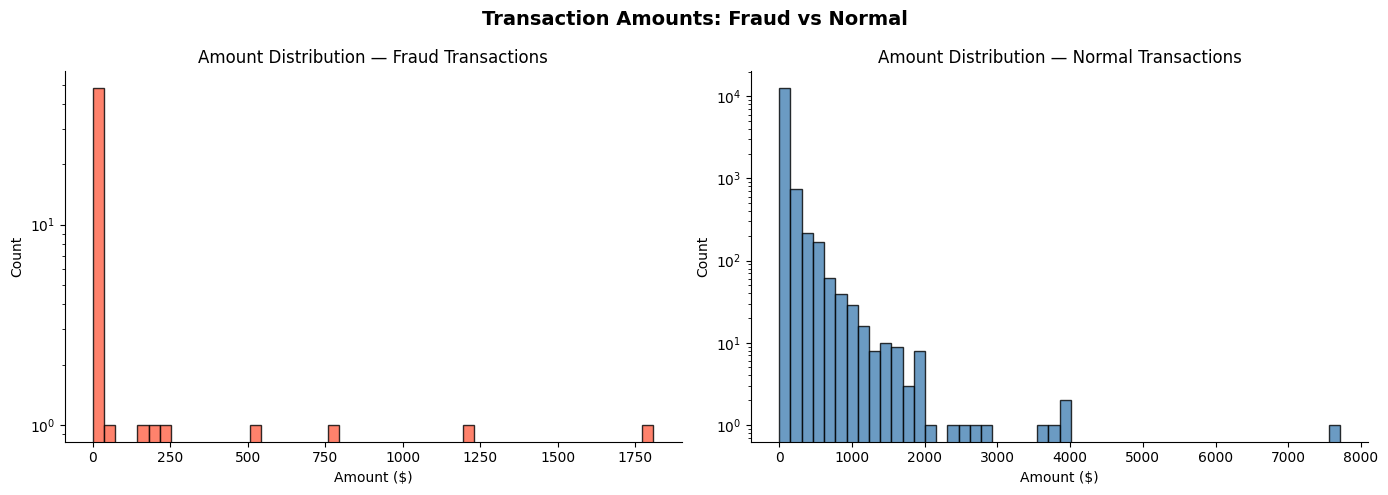

Fraud  — Mean: $90.82  |  Max: $1809.68
Normal — Mean: $63.77  |  Max: $7712.43


In [ ]:
# ─── 3B: Amount Distribution — Fraud vs Normal ───────────────────────────────
fraud_df  = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fraud_df['Amount'],  bins=50, color='tomato',    edgecolor='black', alpha=0.8)
axes[0].set_title('Amount Distribution — Fraud Transactions',  fontsize=12)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')   # Log scale since fraud amounts are scattered

axes[1].hist(normal_df['Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Amount Distribution — Normal Transactions', fontsize=12)
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')

plt.suptitle('Transaction Amounts: Fraud vs Normal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Fraud  — Mean: ${fraud_df['Amount'].mean():.2f}  |  Max: ${fraud_df['Amount'].max():.2f}")
print(f"Normal — Mean: ${normal_df['Amount'].mean():.2f}  |  Max: ${normal_df['Amount'].max():.2f}")

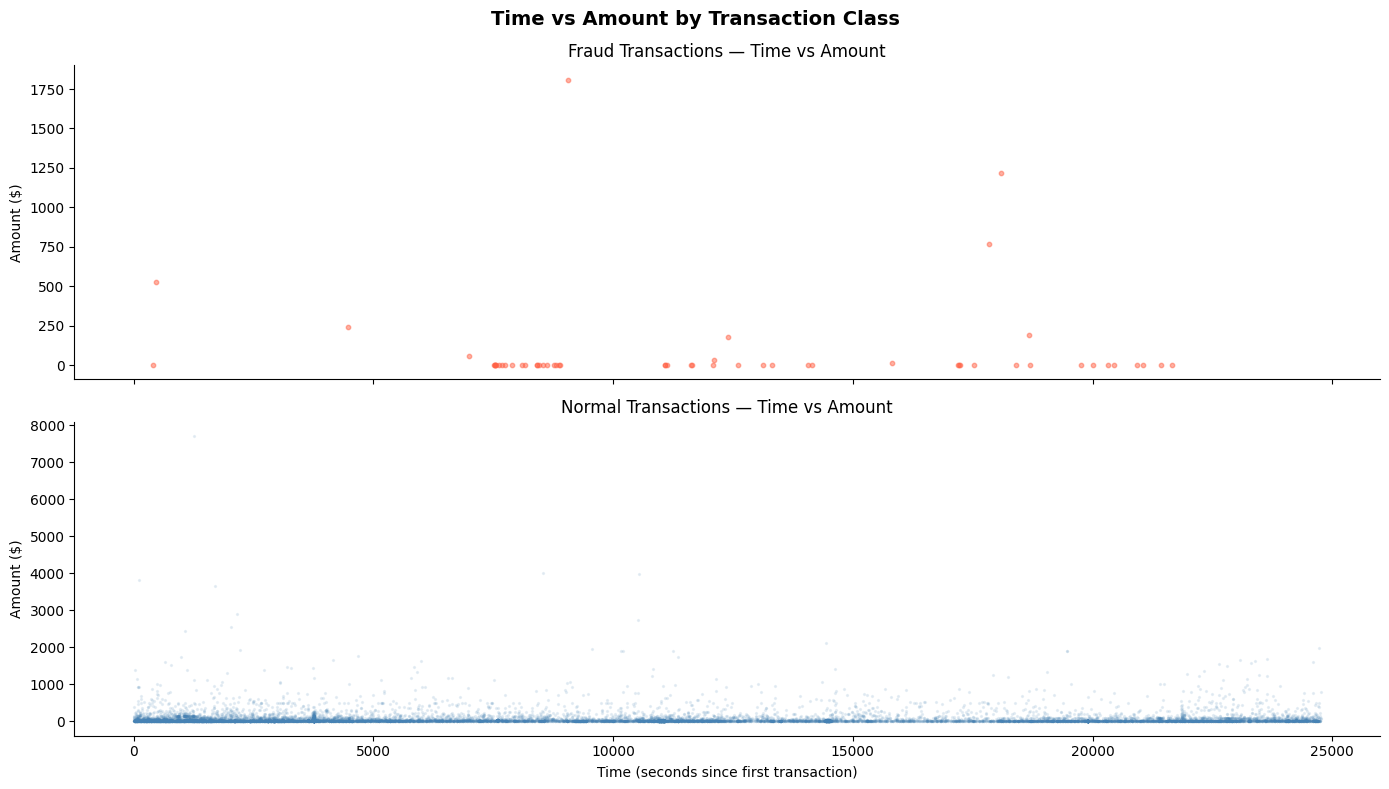

In [ ]:
# ─── 3C: Time vs Amount Scatter — Fraud vs Normal ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].scatter(fraud_df['Time'],  fraud_df['Amount'],
                alpha=0.5, color='tomato',    s=10, label='Fraud')
axes[0].set_title('Fraud Transactions — Time vs Amount', fontsize=12)
axes[0].set_ylabel('Amount ($)')

axes[1].scatter(normal_df['Time'], normal_df['Amount'],
                alpha=0.1, color='steelblue', s=2,  label='Normal')
axes[1].set_title('Normal Transactions — Time vs Amount', fontsize=12)
axes[1].set_ylabel('Amount ($)')
axes[1].set_xlabel('Time (seconds since first transaction)')

plt.suptitle('Time vs Amount by Transaction Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

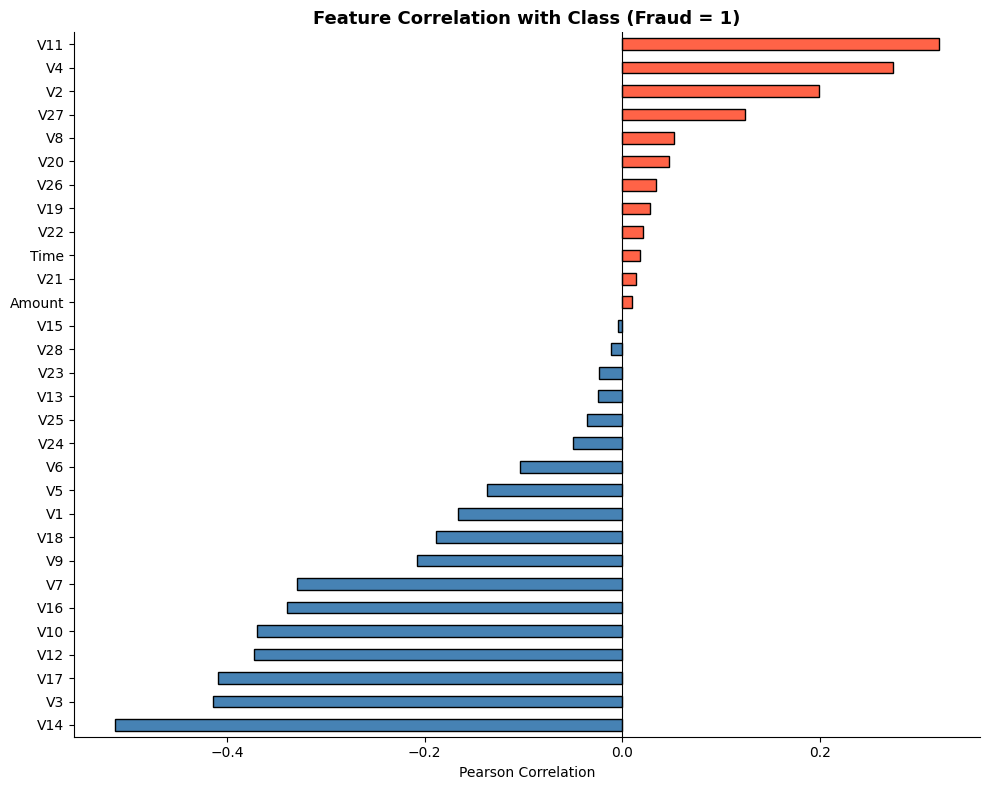

Top 5 positively correlated features : ['V8', 'V27', 'V2', 'V4', 'V11']
Top 5 negatively correlated features : ['V14', 'V3', 'V17', 'V12', 'V10']


In [ ]:
# ─── 3D: Correlation Heatmap ──────────────────────────────────────────────────
# PCA features (V1-V28) are by definition uncorrelated with each other.
# We check correlations with 'Class' to spot the most predictive features.
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
corr_with_class.plot(kind='barh',
                     color=['tomato' if v > 0 else 'steelblue' for v in corr_with_class],
                     edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Class (Fraud = 1)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

top5_pos = corr_with_class.tail(5).index.tolist()
top5_neg = corr_with_class.head(5).index.tolist()
print(f"Top 5 positively correlated features : {top5_pos}")
print(f"Top 5 negatively correlated features : {top5_neg}")

## 🔧 Section 4: Preprocessing & Feature Scaling

**Why RobustScaler?**  
`Time` and `Amount` have very different scales from V1–V28 (which are already PCA-normalized).  
`RobustScaler` uses median and IQR — it's resistant to the extreme outliers present in fraud data.

**Train/Test Split:**  
We use `stratify=y` to preserve the ~0.17% fraud ratio in both train and test sets.  
SMOTE is applied **only on training data** to prevent data leakage.

In [ ]:
# ─── Feature / Target Separation ─────────────────────────────────────────────
# Drop rows with NaN values in the 'Class' column, which cause issues with stratification
df_cleaned = df.dropna(subset=['Class'])
X = df_cleaned.drop(columns=['Class'])
y = df_cleaned['Class']

# ─── Scale Time and Amount (V1-V28 are already PCA-scaled) ───────────────────
scaler = RobustScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# ─── Stratified Train/Test Split (80/20) ─────────────────────────────────────
# stratify=y ensures both splits maintain the same fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Training set   : {X_train.shape} — Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test set       : {X_test.shape}  — Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Training set   : (11162, 30) — Fraud: 45.0 (0.403%)
Test set       : (2791, 30)  — Fraud: 11.0 (0.394%)


## ⚖️ Section 5: Imbalance Handling with SMOTE

**What is SMOTE?**  
SMOTE (Synthetic Minority Over-sampling Technique) generates *synthetic* fraud samples by interpolating between existing fraud samples in feature space — not just duplicating them.

**Why not just duplicate?**  
Simple duplication causes overfitting. SMOTE creates diverse, interpolated examples, making the model more generalisable.

**Data leakage prevention:**  
SMOTE is fit and applied **only** on `X_train / y_train`. The test set is NEVER touched — it stays in its original imbalanced form to reflect real-world conditions.

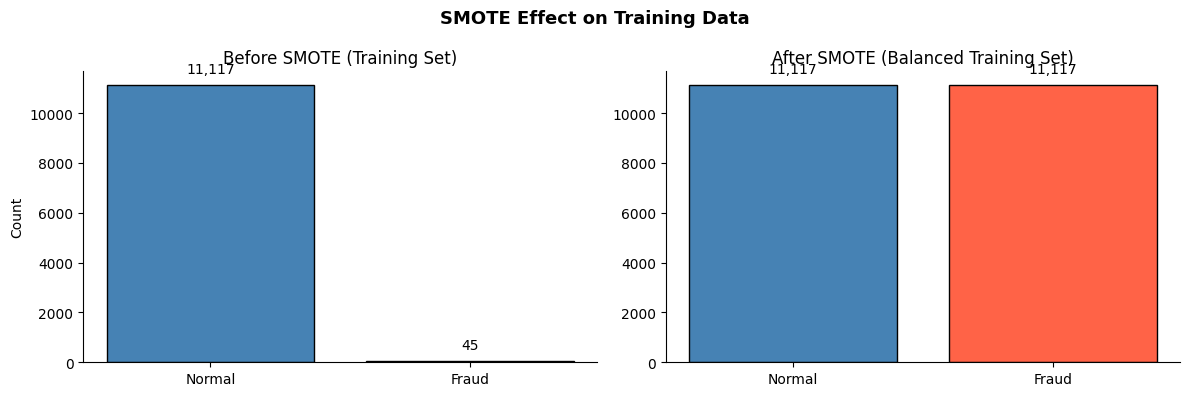

Training size BEFORE SMOTE : 11162  rows
Training size AFTER  SMOTE : 22234 rows  (fraud class now balanced)


In [ ]:
# ─── Apply SMOTE to Training Data ONLY ───────────────────────────────────────
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# ─── Before vs After SMOTE ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = pd.Series(y_train).value_counts()
after  = pd.Series(y_train_sm).value_counts()

axes[0].bar(['Normal', 'Fraud'], before.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Before SMOTE (Training Set)', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values): axes[0].text(i, v+500, f'{v:,}', ha='center')

axes[1].bar(['Normal', 'Fraud'], after.values,  color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('After SMOTE (Balanced Training Set)', fontsize=12)
for i, v in enumerate(after.values): axes[1].text(i, v+500, f'{v:,}', ha='center')

plt.suptitle('SMOTE Effect on Training Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Training size BEFORE SMOTE : {len(X_train)}  rows")
print(f"Training size AFTER  SMOTE : {len(X_train_sm)} rows  (fraud class now balanced)")

## 🌲 Section 6: Model 1 — Isolation Forest (Unsupervised)

**How it works:**  
Isolation Forest builds random trees that recursively split data. Anomalies (fraudulent transactions) require *fewer splits* to isolate — they get shorter path lengths in trees → lower anomaly score.

**Why unsupervised?**  
In real-world scenarios, labelled fraud data may be scarce or unavailable. Isolation Forest learns from the **structure** of the data, not labels.

**Note:** Isolation Forest is trained on the **original imbalanced data** (not SMOTE), because SMOTE is for supervised models only — unsupervised models must see natural distributions.

In [ ]:
# ─── Compute contamination from training labels ───────────────────────────────
# contamination = expected fraction of anomalies in the dataset
contamination = y_train.mean()
print(f"Contamination (fraud ratio in train) : {contamination:.5f}")

# ─── Build & Train Isolation Forest ──────────────────────────────────────────
iso_forest = IsolationForest(
    n_estimators=200,            # More trees = more stable anomaly scores
    max_samples='auto',          # Uses min(256, n_samples) — good default
    contamination=contamination, # Guides the threshold for labelling anomalies
    max_features=1.0,            # Use all features per tree
    bootstrap=False,             # Sampling without replacement
    n_jobs=-1,                   # Use all CPU cores
    random_state=RANDOM_SEED,
    verbose=0
)

# Train on original (imbalanced) training data — NOT SMOTE data
iso_forest.fit(X_train)

# ─── Predict on Test Set ──────────────────────────────────────────────────────
# Isolation Forest returns: +1 (normal) or -1 (anomaly)
# We remap:  +1 → 0 (Not Fraud),  -1 → 1 (Fraud)
iso_raw_pred = iso_forest.predict(X_test)
y_pred_iso   = np.where(iso_raw_pred == -1, 1, 0)

# Anomaly scores (lower = more anomalous)
iso_scores = iso_forest.decision_function(X_test)
iso_scores_inverted = -iso_scores  # Invert so higher = more anomalous (standard convention)

print("\n✅ Isolation Forest trained and predictions generated.")

Contamination (fraud ratio in train) : 0.00403

✅ Isolation Forest trained and predictions generated.


## 🚀 Section 7: Model 2 — XGBoost Classifier (Supervised)

**Why XGBoost?**  
XGBoost is a powerful gradient-boosted tree ensemble that handles tabular data very well. It supports `scale_pos_weight` to internally upweight the minority class — this works in tandem with SMOTE.

**scale_pos_weight:**  
Set to `normal_count / fraud_count` of the **original** training data. This tells XGBoost to penalize missing fraud cases more heavily.

**Training on SMOTE data:**  
XGBoost is trained on the SMOTE-balanced `X_train_sm / y_train_sm` for maximum fraud recall.

In [ ]:
# ─── Compute scale_pos_weight from original training labels ──────────────────
# Higher value = model penalizes missing fraud cases more
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale_pos_weight:.2f} (normal:fraud ratio in raw training data)")

# ─── Build XGBoost Classifier ─────────────────────────────────────────────────
xgb_clf = XGBClassifier(
    n_estimators=300,             # Number of boosting rounds
    max_depth=6,                  # Depth of each tree
    learning_rate=0.05,           # Smaller = more conservative, better generalization
    subsample=0.8,                # Row sampling per tree (reduces overfitting)
    colsample_bytree=0.8,         # Feature sampling per tree
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance natively
    use_label_encoder=False,
    eval_metric='aucpr',          # PR-AUC as XGBoost's internal metric
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0
)

# Train on SMOTE-balanced training data
xgb_clf.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# ─── Predictions ──────────────────────────────────────────────────────────────
y_pred_xgb      = xgb_clf.predict(X_test)              # Binary label (0 or 1)
y_prob_xgb      = xgb_clf.predict_proba(X_test)[:, 1]  # Fraud probability score

print("\n✅ XGBoost trained and predictions generated.")

scale_pos_weight : 247.04 (normal:fraud ratio in raw training data)

✅ XGBoost trained and predictions generated.


## 📈 Section 8: Evaluation — PR-AUC, F1, Confusion Matrix

**Why PR-AUC over ROC-AUC?**  
With heavy class imbalance, ROC-AUC can look great even when the model misses most fraud cases. PR-AUC focuses on the precision-recall trade-off for the *minority class* — it's far more honest.

**Why F1-Score?**  
F1 = harmonic mean of Precision and Recall. It penalizes both false positives AND false negatives equally.

In [ ]:
# ─── Helper: Full Evaluation Report ──────────────────────────────────────────
def evaluate_model(model_name, y_true, y_pred, y_score):
    """
    Prints classification report + PR-AUC and ROC-AUC for a binary classifier.
    y_score = anomaly score (higher = more likely fraud)
    """
    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    f1 = f1_score(y_true, y_pred)

    print(f"{'='*60}")
    print(f"  Model        : {model_name}")
    print(f"  PR-AUC       : {pr_auc:.4f}  ← PRIMARY METRIC")
    print(f"  ROC-AUC      : {roc_auc:.4f}")
    print(f"  F1-Score     : {f1:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))
    return pr_auc, roc_auc, f1

# ─── Evaluate Both Models ─────────────────────────────────────────────────────
iso_pr, iso_roc, iso_f1 = evaluate_model(
    'Isolation Forest',
    y_test, y_pred_iso, iso_scores_inverted
)

xgb_pr, xgb_roc, xgb_f1 = evaluate_model(
    'XGBoost + SMOTE',
    y_test, y_pred_xgb, y_prob_xgb
)

  Model        : Isolation Forest
  PR-AUC       : 0.4453  ← PRIMARY METRIC
  ROC-AUC      : 0.9507
  F1-Score     : 0.5185
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2780
       Fraud       0.44      0.64      0.52        11

    accuracy                           1.00      2791
   macro avg       0.72      0.82      0.76      2791
weighted avg       1.00      1.00      1.00      2791

  Model        : XGBoost + SMOTE
  PR-AUC       : 0.8944  ← PRIMARY METRIC
  ROC-AUC      : 0.9349
  F1-Score     : 0.8000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2780
       Fraud       0.71      0.91      0.80        11

    accuracy                           1.00      2791
   macro avg       0.86      0.95      0.90      2791
weighted avg       1.00      1.00      1.00      2791



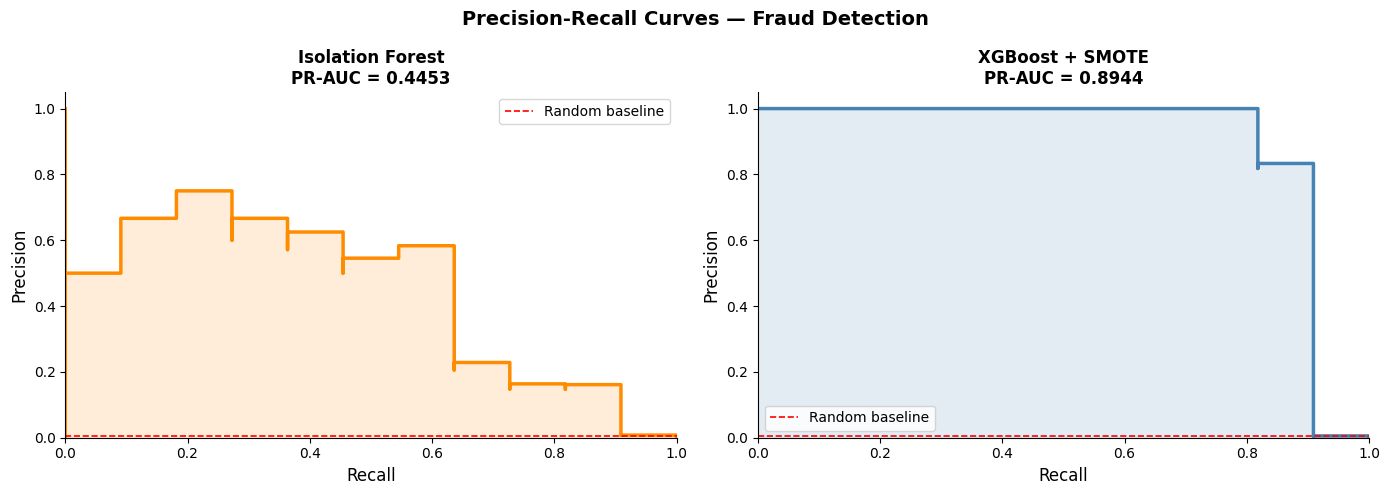

In [ ]:
# ─── Precision-Recall Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_s, pr_auc, color) in zip(axes, [
    ('Isolation Forest', iso_scores_inverted, iso_pr, 'darkorange'),
    ('XGBoost + SMOTE',  y_prob_xgb,          xgb_pr, 'steelblue')
]):
    precision, recall, _ = precision_recall_curve(y_test, y_s)
    ax.step(recall, precision, color=color, linewidth=2.5, where='post')
    ax.fill_between(recall, precision, alpha=0.15, color=color, step='post')
    ax.set_xlabel('Recall',    fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{name}\nPR-AUC = {pr_auc:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    # Baseline = random model (always equals fraud prevalence)
    ax.axhline(y=y_test.mean(), color='red', linestyle='--', linewidth=1.2, label='Random baseline')
    ax.legend(fontsize=10)

plt.suptitle('Precision-Recall Curves — Fraud Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

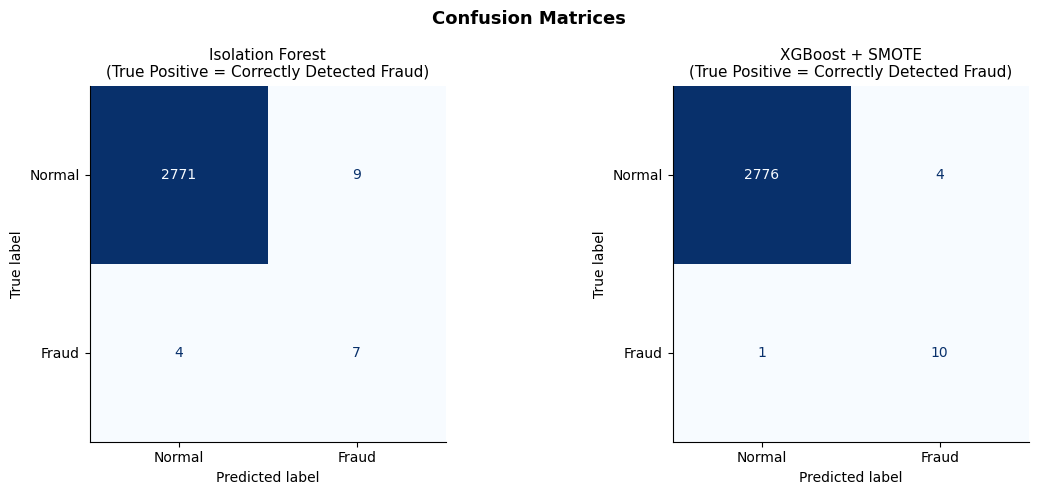

XGBoost — True Positives (Fraud caught): 10 | False Negatives (Fraud missed): 1
IsoForest — True Positives (Fraud caught): 7 | False Negatives (Fraud missed): 4


In [ ]:
# ─── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Isolation Forest', y_pred_iso),
    ('XGBoost + SMOTE',  y_pred_xgb)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Normal', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\n(True Positive = Correctly Detected Fraud)', fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpret
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
print(f"XGBoost — True Positives (Fraud caught): {tp} | False Negatives (Fraud missed): {fn}")
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_iso).ravel()
print(f"IsoForest — True Positives (Fraud caught): {tp} | False Negatives (Fraud missed): {fn}")

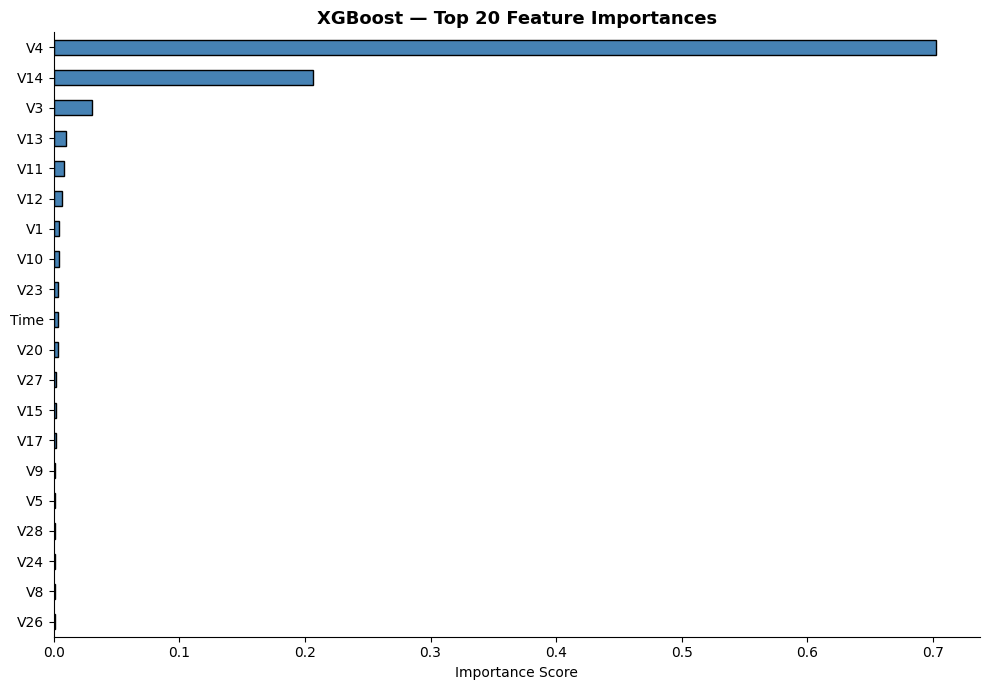

In [ ]:
# ─── Feature Importance (XGBoost) ────────────────────────────────────────────
# Shows which PCA features matter most for predicting fraud
feat_imp = pd.Series(xgb_clf.feature_importances_, index=X.columns)
top_features = feat_imp.nlargest(20)

plt.figure(figsize=(10, 7))
top_features.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('XGBoost — Top 20 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 🏆 Section 9: Model Comparison Summary

                                   PR-AUC   ROC-AUC  F1-Score          Type
Model                                                                      
Isolation Forest (Unsupervised)  0.445329  0.950719  0.518519  Unsupervised
XGBoost + SMOTE (Supervised)     0.894440  0.934925  0.800000    Supervised


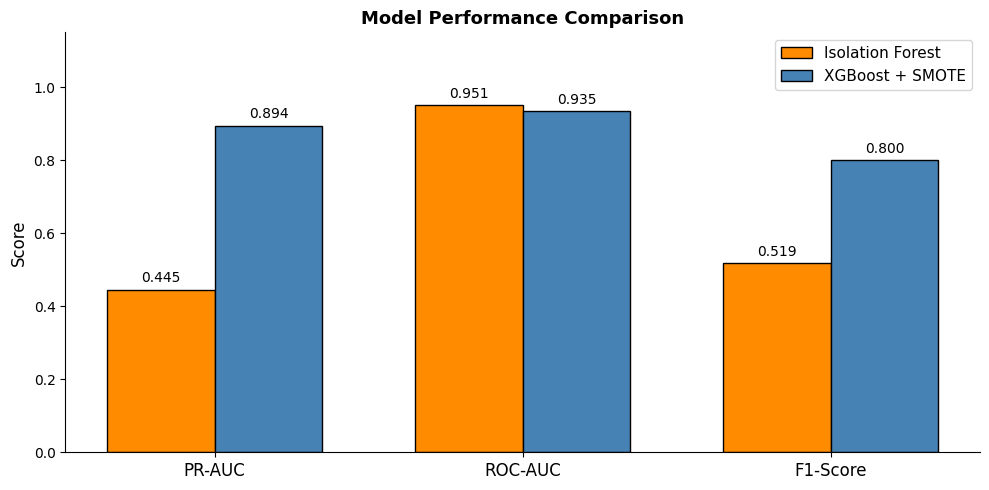

In [ ]:
# ─── Side-by-Side Metric Comparison ──────────────────────────────────────────
results = pd.DataFrame({
    'Model'     : ['Isolation Forest (Unsupervised)', 'XGBoost + SMOTE (Supervised)'],
    'PR-AUC'    : [iso_pr,  xgb_pr],
    'ROC-AUC'   : [iso_roc, xgb_roc],
    'F1-Score'  : [iso_f1,  xgb_f1],
    'Type'      : ['Unsupervised', 'Supervised']
}).set_index('Model')

print(results.to_string())

# ─── Bar Chart Comparison ─────────────────────────────────────────────────────
metrics = ['PR-AUC', 'ROC-AUC', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, results.loc[results.index[0], metrics],
               width, label='Isolation Forest', color='darkorange', edgecolor='black')
bars2 = ax.bar(x + width/2, results.loc[results.index[1], metrics],
               width, label='XGBoost + SMOTE',  color='steelblue',  edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Add score labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 📝 Section 10: Final Takeaways & Learnings

### 🔑 Key Conclusions

| Aspect | Isolation Forest | XGBoost + SMOTE |
|--------|-----------------|------------------|
| Type | Unsupervised | Supervised |
| Labels needed? | ❌ No | ✅ Yes |
| SMOTE applicable? | ❌ No (sees natural distribution) | ✅ Yes |
| PR-AUC | Lower (but label-free) | Higher |
| Best for | Initial detection, no label data | Production systems with labeled history |

### ⚠️ Why Accuracy is NOT the right metric here
- A model that predicts **all transactions as Normal** achieves **99.83% accuracy** — but catches **0 frauds**.
- PR-AUC and F1-Score directly measure how well we catch the rare fraud class.

### 🎯 SMOTE Best Practices
1. **Always fit SMOTE on training data only** — never on test data (causes leakage)
2. **Use `k_neighbors=5`** (default) — interpolates between 5 nearest fraud neighbors
3. **Combine with `scale_pos_weight` in XGBoost** for double imbalance correction

### 🚀 Further Improvements
- Try **LightGBM** with `is_unbalance=True` for faster training
- Explore **ADASYN** (Adaptive Synthetic Sampling) — focuses SMOTE on harder-to-learn samples
- Use **Optuna / RandomizedSearchCV** for hyperparameter tuning
- Deploy with **FastAPI** for real-time inference

## 📥 Download Best Model

In [ ]:
import joblib

# Save the best model (XGBoost + SMOTE) to a file
model_filename = 'best_fraud_model.joblib'
joblib.dump(xgb_clf, model_filename)

print(f"Best model saved as '{model_filename}'")

# To load the model later:
# loaded_model = joblib.load(model_filename)

Best model saved as 'best_fraud_model.joblib'
